In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = '--xla_gpu_enable_command_buffer= --xla_gpu_force_compilation_parallelism=1'
import jax

from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as onp
import jax; print(jax.devices(), jax.__version__)
import jax.numpy as jnp
import jax.random as jr
import optax
from jaxid.common import MLP
import flax.linen as nn

Jax plugin configuration error: Plugin module jax_plugins.xla_cuda12 does not exist
CUDA backend failed to initialize: jaxlib/cuda/versions_helpers.cc:98: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


[CpuDevice(id=0)] 0.4.26


In [2]:
%matplotlib widget
jax.config.update("jax_default_device", jax.devices("cpu")[0])


In [3]:
onp.random.seed(42)
key = jr.key(42)
enc_key, train_key = jr.split(key, 2)

In [4]:
# lower and upper bounds for the sinusoidal dataset parameters
xl = -5.0
xu = 5.0
al = 0.5
au = 2.0
pl = 0.0
pu = jnp.pi
noise_std =  0.01
# beta = 1

In [5]:
meta_train_size = 1000 # meta-training dataset size
meta_test_size = 100 # meta-testing dataset size
size_train = 200 # K-shot regression
size_test = 10 # In test, very scarce data!
#emb_size = 2 # 2 as the true latent dimension
emb_size = 2
iters = 10_000
lr = 1e-2

In [6]:
batch_size = meta_train_size # actually, a "meta" batch size
K = size_train # number of "shots", actually an "inner" batch size, se questo aumenta la NLL loss viene premiata rispetto alla KL.
latent_dim = emb_size # in principle, phase and amplitude should be enough!
sigma_noise = noise_std

In [7]:
def sample_datasets(key, meta_size, size, noise_std=0.0, return_params=False):

    """
    Sample a batch of tasks from the sine function with random phases and amplitudes.
    Each task is defined by a different amplitude and phase shift.
    """
    key_amp, key_phase, key_x, key_e = jr.split(key, 4)
    
    amplitudes = jr.uniform(key_amp, shape=(meta_size,), minval=al, maxval=au)
    phases = jr.uniform(key_phase, shape=(meta_size,), minval=pl, maxval=pu)
    batch_x = jr.uniform(key_x, shape=(meta_size, size), minval=xl, maxval=xu)
    # batch_x = jnp.sort(batch_x, axis=1)
    batch_y = amplitudes[:, None] * jnp.sin(batch_x + phases[:, None])
    batch_y += jr.normal(key_e, shape=batch_y.shape) * noise_std  # Add noise

    batch_x = batch_x[..., None]
    batch_y = batch_y[..., None]
    
    if return_params:
        # Return the parameters used to generate the tasks, useful for performance evaluation and plotting
        return batch_x, batch_y, amplitudes, phases
    else:
        # Return only the inputs and outputs
        return batch_x, batch_y

In [8]:
key, subkey = jr.split(key)
meta_x_train, meta_y_train = sample_datasets(key,meta_train_size, size_train, noise_std=noise_std)

key, subkey = jr.split(key)
meta_x_test, meta_y_test, amplitudes, phases = sample_datasets(key,meta_test_size, size_test, noise_std=noise_std, return_params=True)

In [9]:
x_dense = jnp.linspace(xl, xu, 1000)
meta_y_test_dense = amplitudes[:, None] * jnp.sin(x_dense + phases[:, None])

# --- NEW: same normalization as in sample_datasets ---
y_mean = meta_y_test_dense.mean(axis=1, keepdims=True)
y_std  = meta_y_test_dense.std(axis=1, keepdims=True) + 1e-8
x_expanded = jnp.broadcast_to(x_dense[None, :, None], (100, 1000, 1))
# meta_y_test_dense = (meta_y_test_dense - y_mean) / y_std

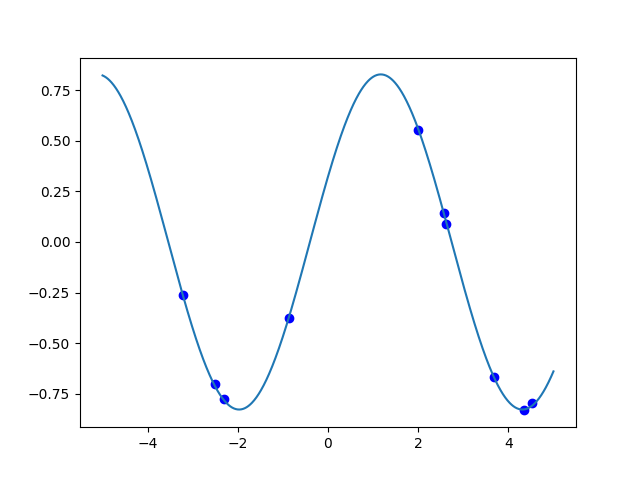

In [10]:
plt.figure()
idx  = 53
plt.plot(meta_x_test[idx], meta_y_test[idx], "bo")
plt.plot(x_dense,meta_y_test_dense[idx])


# Setting
We consider a *static* regression setting from $x \in \mathbb{R}^{n_x}$ to $y \in \mathbb{R}^{n_y}$

* We can sample input/output datasets $\mathcal{D} = (X, Y) = (x_{1:N}, y_{1:N})$ from a (possibly unknown) distribution $p(\mathcal{D}) = p(X, Y)$
* We assume that there is a latent factor $z \in \mathbb{R}^{n_z}$ that influences the data generation process:

$$p(x, y, z) = p(z) \prod_i p(x_i) p(y_i|x_i, z),$$
with the understanding that the probabilities at the different indexes are the identical (i.e. $p(x_i) = p(x_j), p(y_i | x_i) = p(y_j | x_j)$)

Note that the latent factor influences the conditional generation of $y$.

For instance, the multisine example above is formalized as:
* $z_1, z_2$ are the amplitude and phase of the sinusoids, respectively with $z_1 \sim \textrm{Unif}(1, 2)$ and $z_2 \sim \textrm{Unif}(0, 2\pi)$
* $x_i, \sim \textrm{Unif} [-5. 5]$ 
* $p(y_i | x_i, z) = \mathcal{N}(y_i; z_1\sin(x + z_2), \sigma^2_e)$


# Meta Learning
In meta learning for supervised regression, informally, we want to get better at solving the supervised regression problem $x \rightarrow y$ by observing more and more datasets $(X, Y)$ from $p(X, Y)$


## Meta train and meta test datasets

Some meta learning techniques require two datasets from each data-generating system (thus, generated by the *same* latent $z$).  Let us call them $(X^1, Y^2)$ and $(X^2, Y^2)$, respectively.  In practice, we can imagine splitting each dataset $(X, Y)$ in two portions of length $K$ and $N-K$, resepectively:

\begin{align}
X^1 &= x_{1:K}    &Y^1 &= y_{1:K}\\
X^2 &= x_{K+1:N}  &Y^2 &= y_{K+1:N}
\end{align}

The two datasets will be used for meta training and meta testing, respectively.

## Base learner
Some meta learning techniques require the definition of a *base learner*, ie a parametric model structure with structure:

\begin{equation}
\hat y = F_{\theta}(x),
\end{equation}

where $\theta$ are free parameters. In a probabilistic setting, the base learner is extended to a parametric conditional distribution $p_{\theta}(y | x)$. The simplest extension from deterministic to probabilistic arguably is:

\begin{equation}
p_\theta(y | x) = \mathcal{N}(y; F_\theta(x), \sigma^2_e)
\end{equation}

Intuitively, the base learner should be chosen rich enough to capture all the relationship $x \rightarrow y$ in the datasets where $p(x, y)$ has support. Meta learning will eventually lead to an algorithm 
that, given a dataset $(x, y)$, return a model parameterized as the base learning.


## In-context learning approach

We model directly the distribution $p(Y^2 | X^2, X^1, Y^1)$ with a parametric approximation $q_{\phi} (Y^2 | X^2, X^1, Y^1)$, also known as meta-model. 
Since we are in static regression, we actually use a factorized probability:
$$q_\phi(Y^2 | X^2, X^1, Y^1) = \prod_i q_\phi(y^2_i | x^2_i, X^1, Y^1),$$
since there's no reason to assume a different models for the different observations, nor to have influence from $x_j$ to $y_i$ for $i \neq j$ for a static regression problem.

For learning, we minimize

\begin{equation}
\mathrm{D_{KL}} (p(Y^2 | X^2, X^1, Y^1) \; || \; q_{\phi}(Y^2 | X^2, X^1, Y^1))
\end{equation}

by sampling from $p$. 
Intuitively, the meta-model has to understand the data generating system from $(X^1, Y^1)$ and apply the knowledge on $X^2$ to solve the task. Thus, it need to have a high capacity (much higher than the one of a 
base learner) because it needs to represent a learning algorithm, and not just a relationship. For instance, even in the case where the relationship $x \rightarrow y$ is linear, the meta-model must internally 
perform least-squares.


Once it is trained, the in-context learner can be seen as a non-parametric model. If we receive a ``real'' training dataset $(x^{tr}, y^{tr})$, our model of the relation $x \rightarrow y$ becomes
the meta-model with fixed second and third arguments:

\begin{equation}
 q_{\phi}(y | x, X^{tr}, Y^{{tr}})
\end{equation}

The model carries over the entrire training dataset, it is thus *non-parametric* (such as a GP or a K-NN) 

## MAML approach
This approach makes use of a deterministic base learner $F_\theta$

\begin{align}
\arg \min_{\phi} \sum_{i=1}^N \mathcal{L}(Y^2, F_{\theta^*(\phi, X^1, Y^1)}(X^2))
\end{align}

Where $\theta^*$ is the base learner parameter fitted on $(X^1, Y^2)$, with $\phi$ controlling some details of the fitting algorithm. For instance, iMAML looks like:

\begin{equation}
\theta^* = \arg \min_{\theta} \mathcal{L}(Y^1, F(X^1)) + \gamma || \theta - \phi||^2,
\end{equation}

i.e., $\phi$ controls the center of the regularization.

We note that iMAML looks a lot like a MAP approximation + pointwise uncertainty propagation of a Bayesian regression with a (learned) Gaussian prior centered in $\phi$.
In fact, probabilitic interpretations of MAML and derivatives have been discussed in the literature.



## VAE Approach

In practice, the probabilistic structure is not known explicitly. However, we can try to model it with a conditional VAE, with the understanding that the learned $z$ has no reason to correspond to the $z$ above.

\begin{align}
p(z) &= \mathcal{N}(z; 0, I_{n_z}) \\
p_{\phi}(Y | X, z) &= \prod_i \mathcal{N}(y_i; F_{\phi}(x_i, z), \sigma^2_e)
\end{align}

To learn such a model, we also introduce the probabilistic encoder:

\begin{equation}
q_{\psi} (z | x, y) = \mathrm{MLP}_{\psi}(\rm{vec}(X, Y))
\end{equation}


The VAE approach requires a slightly modified base learner $F_{\phi}(\cdot, z)$ that accepts 2 parameters: the decoder parameters $\phi$, which are common to all data generating systems, and the latent parameters $z$ that depend on the particular data generating system. The encoder network has arguably the hardest task, as it must act like a parametric system identification algorithm 
$(x, y) \rightarrow z$.

We train the VAE using standard approaches... 


After training of the VAE, we can sample from the decoder to judge if we qualitatively learned a meaningful prior for the problem class

\begin{equation}
F_{\hat \phi}(x^{(i)}, z^{(i)}), i=1,2,\dots
\end{equation}
We would check whether the $(x, y)$ pairs from the decoder ''look like'' genuine datasets from $p(\mathcal{D})$
In other words, we run a prior predictive check for the learned prior!


Finally, when a real dataset comes in, we would fit the latent parameters according to:

\begin{equation}
\arg \min_z \mathcal{L} (y^{tr}, F_{\phi}(u^{tr}, z)) + ||z||^2,
\end{equation}
that, if the loss $\mathcal{L}$ is the negative log-likelihood, is the MAP estimate under the generative model (that models the data, if the VAE is trained successfully!)


We also note that we may also alternatively try to find $z$ simply by passing through the encoder, as it also returns an (approximate) posterior of $z$! However, minimizing
a fitting loss function is arguably ''safer'' and more robust than relying on an approximate posterior.


## Hierarchical Bayesian Model, MCMC

You might learn the common knowledge with a hierarchical bayesian model. Then, derive simple (non-hierarchical) priors!

Check out the awesome blog post https://twiecki.io/blog/2018/08/13/hierarchical_bayesian_neural_network/



In [11]:
class Encoder(nn.Module):
    hidden_size: int
    output_size: int

    @nn.compact
    def __call__(self, y, x):

        # Apply a shared MLP to each element in the set
        in_feat = jnp.concat((y, x), axis=-1)
        x = nn.Dense(self.hidden_size)(in_feat)
        x = nn.relu(x)
        x = nn.Dense(self.hidden_size)(x)
        x = nn.relu(x)

        # Aggregate the set using a permutation-invariant operation (e.g., sum)
        x = jnp.mean(x, axis=-2)

        # Apply another MLP to the aggregated representation
        x = nn.Dense(self.hidden_size)(x)
        x = nn.relu(x)
        enc_mean = nn.Dense(self.output_size)(x)
        enc_logstd = nn.Dense(self.output_size)(x)
        return enc_mean, enc_logstd

In [12]:
enc = Encoder(hidden_size = 64,output_size=latent_dim)
dummy_latent, params_enc = enc.init_with_output(enc_key, jnp.ones((K, 1)), jnp.ones((K, 1)))

In [13]:
z = dummy_latent[0] # actually, z sampled from gaussian
# z.shape, x.shape,jnp.tile(z.reshape(1, -1), (x.shape[-2], 1)).shape

In [14]:
  
# Initialize the MLP
mlp2 = MLP([64, 32, 16,1])

key, subkey = jr.split(key)
params_mlp = mlp2.init(subkey, jnp.ones((1,)))

# Initialize the MLP
_, mlp_unflatten = jax.flatten_util.ravel_pytree(params_mlp)
n_params = sum(jnp.size(p) for p in jax.tree_util.tree_leaves(params_mlp))
n_params
# Lifting function, ie model from embedded to full parameter space
from typing import Callable

class Lifting(nn.Module):
    outputs: int
    unflatten: Callable

    def setup(self):
        self.net = nn.Dense(self.outputs, use_bias=False)


    def __call__(self, z):
        out = self.net(z)
        return self.unflatten(out)
    
# Initialize the Lifting
lift = Lifting(outputs=n_params, unflatten=mlp_unflatten)
key, subkey = jr.split(key)
params_lift = lift.init(subkey, jnp.ones((emb_size,)))
params_lift = jax.tree_util.tree_map(lambda w: w / 20.0, params_lift) # to start the NLL from 1


# mlp_emb_apply: handles BOTH (latent_dim,) AND (batch, latent_dim)
def mlp_emb_apply(z, p_mlp, p_lift, x):
    """
    z: scalar, (latent_dim,), or (batch, latent_dim)
    x: (K, 1) or (batch, K, 1)
    """
    
    # Define the base function that processes exactly ONE z and ONE x trajectory
    def single_emb_apply(z_flat, x_single):
        # Ensure z_flat is at least 1D
        z_flat = jnp.atleast_1d(z_flat).reshape((latent_dim,))
        
        p_upd = lift.apply(p_lift, z_flat)
        p_new = jax.tree_util.tree_map(lambda x_, y_: x_ + y_, p_upd, p_mlp)
        return mlp2.apply(p_new, x_single)

    # 1. Handle scalar z or 1D z (single sample)
    if z.ndim == 0 or z.ndim == 1:
        # If z is unbatched, x must also be unbatched (shape K, 1)
        if x.ndim == 3:  # User accidentally passed batched x with unbatched z
            raise ValueError("If z is unbatched, x must also be unbatched (K, 1).")
        return single_emb_apply(z, x)
    
    # 2. Batched z (shape: B, latent_dim)
    if z.ndim == 2:
        # If z is batched, x must be batched (B, K, 1)
        # We vmap over axis 0 of z AND axis 0 of x
        return jax.vmap(single_emb_apply, in_axes=(0, 0))(z, x)
    
    raise ValueError(f"Unexpected z dimension: {z.ndim}")


mlp_emb_apply(jnp.zeros(emb_size), params_mlp, params_lift, jnp.zeros((size_train, 1))).shape


(200, 1)

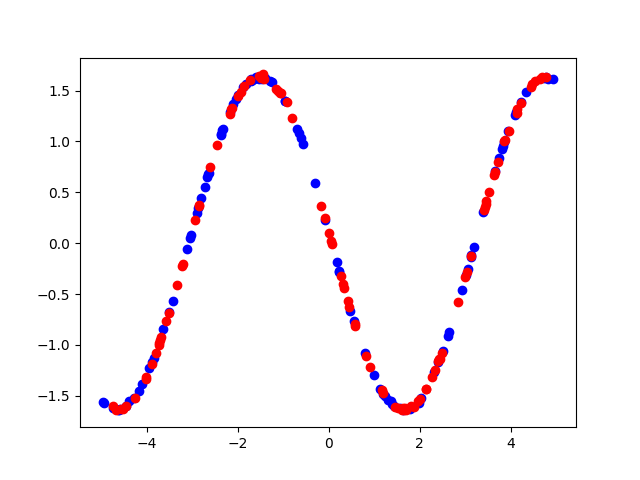

In [15]:
# Traditional training overfits
meta_x1_train, meta_y1_train = meta_x_train[:, :size_train//2], meta_y_train[:, :size_train//2]
meta_x2_train, meta_y2_train = meta_x_train[:, size_train//2:], meta_y_train[:, size_train//2:]# A single realization

x_1 = meta_x1_train[0]
y_1 = meta_y1_train[0]
x_2 = meta_x2_train[0]
y_2 = meta_y2_train[0]
plt.figure()
plt.plot(x_1, y_1, "bo")
plt.plot(x_2, y_2, "ro")


In [16]:

beta = 0.1

def instance_loss_fn_vae(p, y1, u1, y2, u2, key):


    (p_enc, p_mlp, p_lift, log_sigma_est) = p
    sigma_est = jnp.exp(log_sigma_est)
    #batch_size = x.shape[0]

    # Process through the encoder
    enc_mean, enc_logstd = enc.apply(p_enc, y1, u1)
    enc_std = jnp.exp(enc_logstd)

    # Re-parameterization trick
    z = enc_mean + jr.normal(key, enc_mean.shape) * enc_std

    decoded_y = mlp_emb_apply(z,p_mlp, p_lift, u2)

    # -log p(y | latent) with Gaussian p(y | latent), with fixed known std
    scaled_err = (y2 - decoded_y)/(sigma_est+1e-4) # 
    nll_loss = 0.5 * jnp.sum((scaled_err)**2) + y2.shape[0] * log_sigma_est + y2.shape[0]/2 * jnp.log(2*jnp.pi)
    #nll_loss = 0.5 * jnp.sum((y - decoded_y)**2)

    # - KL(N(mean, std^2) || N(0, 1))
    kl_loss = 0.5 * jnp.mean(enc_mean**2 + enc_std**2 - 2 * jnp.log(enc_std) - 1)

     # just a scaling for numerical reason   dd
    nll_loss = nll_loss / y2.shape[0]# / 30
    kl_loss = kl_loss #/ y.shape[0]# / 30

    total_loss = nll_loss + beta * kl_loss
    total_loss = total_loss 
    return  total_loss, nll_loss 

instance_loss_fn = instance_loss_fn_vae

# Batched loss
def loss_fn(params, y1, u1, y2, u2, key):
    # Notice the in_axes: None for params, 0 for the 5 batched inputs
    total_loss, nll_loss = jax.vmap(instance_loss_fn, in_axes=(None, 0, 0, 0, 0, 0))(
        params, y1, u1, y2, u2, key
    )
    return jnp.mean(total_loss), jnp.mean(nll_loss)

loss_grad_fn = jax.jit(jax.value_and_grad(loss_fn, has_aux=True))   

In [18]:
instance_loss_fn((params_enc, params_mlp, params_lift, jnp.array(0.0)), y_1, x_1, y_2, x_2, jr.key(0))
loss_fn((params_enc, params_mlp, params_lift, jnp.array(0.0)), meta_y1_train, meta_x1_train,meta_y2_train, meta_x2_train, jr.split(train_key, meta_x1_train.shape[0]))

(Array(1.4860166, dtype=float32), Array(1.417766, dtype=float32))

In [19]:
params = (params_enc, params_mlp, params_lift, jnp.array(0.0))
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

In [20]:
LOSS = []
NLL_LOSS = []

for itr in (pbar := tqdm(range(iters))):
    # key, subkey = jr.split(key, 2)
    # batch_x, batch_y = sample_datasets(subkey, batch_size, K, noise_std=sigma_noise)

    train_key, train_subkey = jr.split(train_key, 2) # subkey to be consumed at the current iteration
    train_keys = jr.split(train_subkey, batch_size)  # one key per sample 
    (loss, nll_loss),  grads = loss_grad_fn(params, meta_y1_train, meta_x1_train,meta_y2_train, meta_x2_train, train_keys)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    LOSS.append(loss.item())
    NLL_LOSS.append(nll_loss.item())
    if itr % 400 == 0:
        pbar.set_postfix_str(f"total_loss:{loss.item():.2f} nll_loss:{nll_loss.item():.2f}")
    if itr == iters:
        break

100%|██████████| 10000/10000 [43:46<00:00,  3.81it/s, total_loss:-1.44 nll_loss:-1.89]


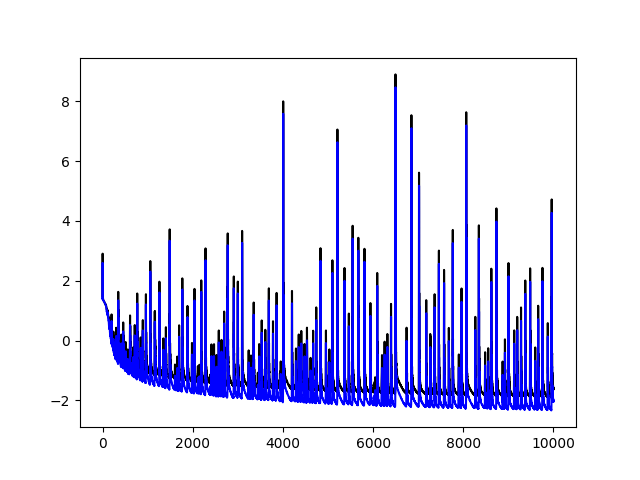

In [22]:
LOSS = onp.array(LOSS)
NLL_LOSS = onp.array(NLL_LOSS)
KL_LOSS = LOSS - NLL_LOSS

plt.figure()
plt.plot(LOSS, "k", label="total")
plt.plot(NLL_LOSS, "b", label="nll")

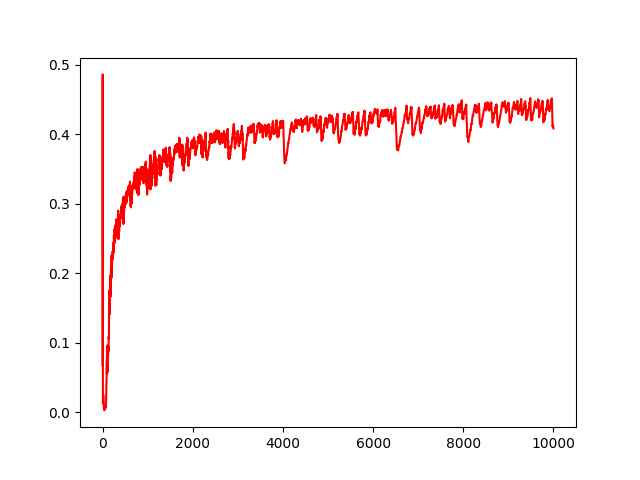

In [23]:

plt.figure()
plt.plot(KL_LOSS, "r", label="kl")


In [25]:
params_enc_opt, params_mlp_opt, params_lift_opt, log_std_opt = params

In [26]:
std_opt = jnp.exp(log_std_opt)
std_opt

Array(0.04197757, dtype=float32)

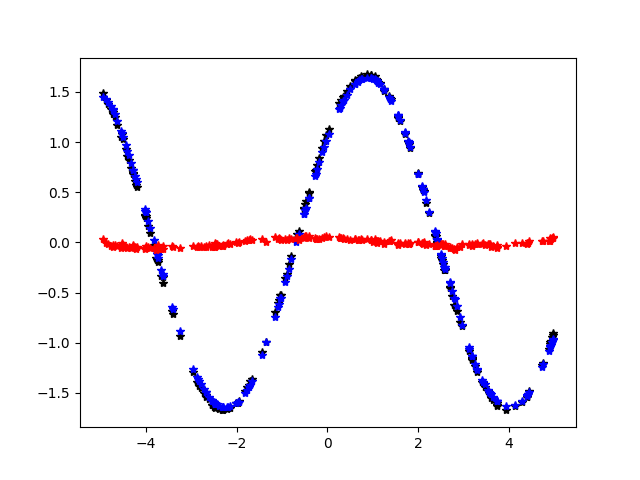

In [27]:
# Reconstruction
enc_mean, enc_logstd = enc.apply(params_enc_opt, meta_y_train, meta_x_train)
enc_std = jnp.exp(enc_logstd) * 0.0
z_cond = enc_mean + onp.random.randn(*enc_std.shape) * enc_std
batch_y_rec = jax.vmap(mlp_emb_apply, in_axes=(0, None, None, 0))(z_cond, params_mlp_opt, params_lift_opt, meta_x_train)

idx = 1
plt.figure()
plt.plot(meta_x_train[idx], meta_y_train[idx], "k*", label="true")
plt.plot(meta_x_train[idx], batch_y_rec[idx], "b*", label="reconstructed")
plt.plot(meta_x_train[idx], meta_y_train[idx] - batch_y_rec[idx], "r*", label="reconstruction error")

In [29]:
# Pass the full meta-test batch through the trained encoder
# Ensure that 'params_enc' refers to your trained encoder parameters
enc_mean, enc_logstd = enc.apply(params_enc, meta_y_train, meta_x_train)

# Convert log standard deviation to actual standard deviation
enc_std = jnp.exp(enc_logstd)

# 1. Look at the standard deviations for a single test dataset
print("Standard Deviations for the first test set (10 dimensions):")
print(jnp.round(enc_std[0], 3))

# 2. Average the std over the entire meta-test batch 
# Dimensions that are shut down will have std ~ 1.0. Active dimensions will have std < 1.0.
mean_std_across_datasets = jnp.mean(enc_std, axis=0)

print("\nAverage Standard Deviation across all test datasets:")
print(jnp.round(mean_std_across_datasets, 3))

# 3. Compute the average KL divergence per dimension across the test set
# A KL divergence of exactly 0.0 means the dimension is completely shut down (pruned).
# Active dimensions will have a KL divergence > 0.
kl_per_dim = 0.5 * jnp.mean(enc_mean**2 + enc_std**2 - 2 * jnp.log(enc_std) - 1, axis=0)

print("\nAverage KL Divergence per dimension (0 means pruned):")
print(jnp.round(kl_per_dim, 3))


Standard Deviations for the first test set (10 dimensions):
[0.85200006 2.319     ]

Average Standard Deviation across all test datasets:
[0.804     2.1560001]

Average KL Divergence per dimension (0 means pruned):
[0.21100001 1.148     ]


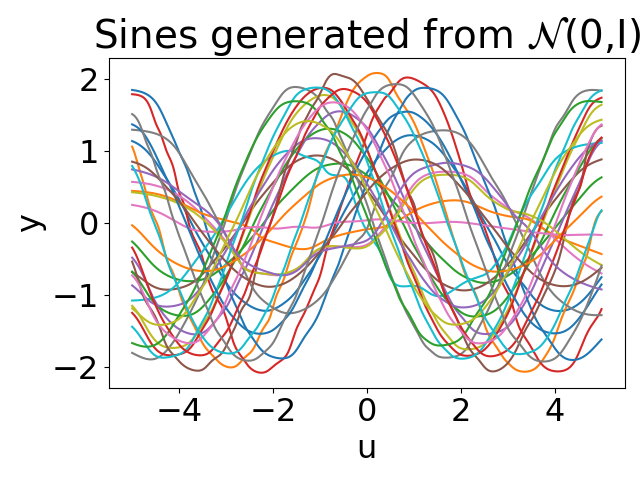

In [33]:
# Unconditional generation from the initial decoder, with latent from the prior
onp.random.seed(42)
z = onp.random.normal(size=(30, latent_dim))
# x_dense = jnp.linspace(-5, 5, 1_000).reshape(-1, 1)
y_pred = jax.vmap(mlp_emb_apply, in_axes=(0, None, None, None))(z, params_mlp_opt, params_lift_opt,  x_dense[:, None])
plt.figure()
plt.title(r"Sines generated from $\mathcal{N}$(0,I)", fontsize = 28)
plt.plot(x_dense, y_pred.squeeze(-1).T);
plt.xlabel("u", fontsize = 23)
plt.ylabel("y", fontsize = 23)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
plt.savefig('sines_generation.pdf')


In [34]:
import numpy as np
from scipy.optimize import curve_fit

# 1. Define the mathematical sine function (fixing frequency w = 1.0)
def sine_curve(x, A, phase, offset):
    return A * np.sin(1.0 * x + phase) + offset

# Ensure x_dense is a standard 1D numpy array
x_fit = np.array(x_dense).flatten()

# Lists to store the successfully extracted values
extracted_amplitudes = []
extracted_phases = []

print("--- Extracting Parameters ---")
# 2. Loop through each generated trajectory in y_pred
for i in range(y_pred.shape[0]):
    y_fit = np.array(y_pred[i]).flatten()
    
    # Initial guesses
    guess_A = (np.max(y_fit) - np.min(y_fit)) / 2.0
    guess_offset = np.mean(y_fit)
    guess_phase = 0.0
    
    initial_guess = [guess_A, guess_phase, guess_offset]
    
    try:
        # Fit the curve
        popt, _ = curve_fit(sine_curve, x_fit, y_fit, p0=initial_guess)
        A_est, phase_est, offset_est = popt
        
        # Normalize amplitude to be positive
        amplitude = abs(A_est)
        
        # Normalize phase to be strictly between 0 and 2*pi
        phase = phase_est % (2 * np.pi)
        if A_est < 0:
            phase = (phase + np.pi) % (2 * np.pi)
            
        extracted_amplitudes.append(amplitude)
        extracted_phases.append(phase)
        
    except RuntimeError:
        pass # Skip if the fit fails for a specific sample

# 3. Calculate and print the ranges
if len(extracted_amplitudes) > 0:
    min_amp = np.min(extracted_amplitudes)
    max_amp = np.max(extracted_amplitudes)
    
    min_phase = np.min(extracted_phases)
    max_phase = np.max(extracted_phases)
    
    print("\n--- Final Range Analysis ---")
    print(f"Generated Amplitude Range: [{min_amp:.3f}, {max_amp:.3f}]  (Target: [0.5, 2.0])")
    print(f"Generated Phase Range:     [{min_phase:.3f}, {max_phase:.3f}]  (Target: [0.0, 3.14])")
else:
    print("Could not extract parameters from any of the generated lines.")


--- Extracting Parameters ---

--- Final Range Analysis ---
Generated Amplitude Range: [0.104, 2.048]  (Target: [0.5, 2.0])
Generated Phase Range:     [0.010, 6.240]  (Target: [0.0, 3.14])


In [35]:
# Traditional training overfits
x1, y1 = meta_x_test[:, :size_test//2], meta_y_test[:, :size_test//2]
x2, y2 = meta_x_test[:, size_test//2:], meta_y_test[:, size_test//2:]

In [36]:
import jax
import jax.numpy as jnp
import optax
from tqdm.auto import tqdm

def train_decoder_batched(z_batch, x_batch, y_batch, iters=20_000, lr=1e-3):
    # 1. Define loss_fn for a SINGLE trajectory
    def loss_fn(z, x, y):
        # z: (latent_dim,) | x: (N, d_x) | y: (N, d_y)
        y_hat = mlp_emb_apply(z, params_mlp_opt, params_lift_opt, x)
        scaled_err = (y - y_hat) / (std_opt + 1e-4)

        nll_loss = 0.5 * jnp.sum(scaled_err**2) / y.shape[0]
        reg_loss = 0.5 * jnp.sum(z**2) / y.shape[0]
        
        loss = nll_loss + reg_loss
        return loss, nll_loss
    
    # 2. Vectorize the gradient computation over the batch dimension.
    # in_axes=(0, 0, 0) maps over the first axis of z_batch, x_batch, and y_batch.
    loss_grad_fn = jax.jit(jax.vmap(jax.value_and_grad(loss_fn, has_aux=True), in_axes=(0, 0, 0)))

    train_loss = []
    
    # 3. optax state will automatically adapt to the batched shape of z_batch
    opt = optax.adam(learning_rate=lr)
    opt_state = opt.init(z_batch)

    for _ in (pbar := tqdm(range(iters))):
        # Compute batched losses and batched gradients
        (loss_batch, nll_loss_batch), grads_batch = loss_grad_fn(z_batch, x_batch, y_batch)
        
        # 4. Update the batched z
        upd, opt_state = opt.update(grads_batch, opt_state)
        z_batch = optax.apply_updates(z_batch, upd)
        
        # Track the mean loss across the batch for logging
        mean_loss = jnp.mean(loss_batch)
        
        # Append .item() to cast to a standard Python float (prevents JAX memory leaks)
        train_loss.append(mean_loss.item()) 
        pbar.set_postfix_str(f"mean_loss: {mean_loss:.4f}")
        
    return z_batch, train_loss

# key, subkey = jr.split(key)
# z0 = jr.normal(subkey, shape=(meta_test_size, latent_dim))
# mean_enc, _ = enc.apply(params_enc_opt,x1, y1)
latent_opt, train_loss_latent = train_decoder_batched(jnp.zeros((meta_test_size, latent_dim)), x1, y1)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [39]:
y1_hat_dec = mlp_emb_apply(latent_opt, params_mlp_opt, params_lift_opt, x1)#* std_opt
y2_hat_dec = mlp_emb_apply(latent_opt, params_mlp_opt, params_lift_opt, x2)#* std_opt
y_hat_dec = mlp_emb_apply(latent_opt, params_mlp_opt, params_lift_opt, x_expanded)#* std_opt

In [40]:
jnp.sqrt(jnp.mean((y1_hat_dec - y1)**2)), jnp.sqrt(jnp.mean((y2_hat_dec - y2)**2))

(Array(0.01317619, dtype=float32), Array(0.01980143, dtype=float32))

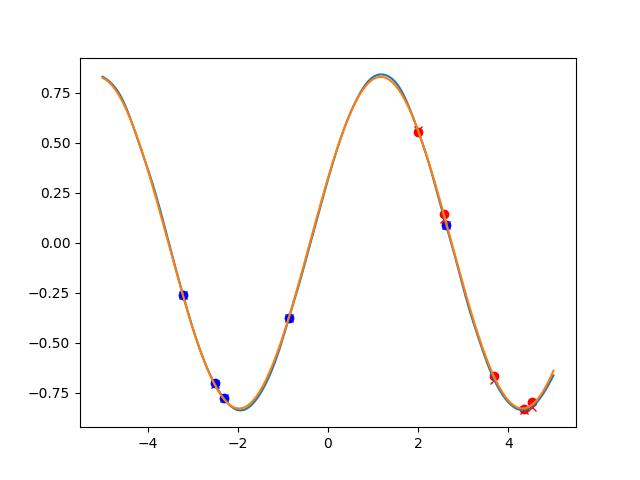

In [41]:
plt.figure()
idx  = 53
plt.plot(x1[idx], y1[idx], "bo")
plt.plot(x1[idx], y1_hat_dec[idx], "bx")

plt.plot(x2[idx], y2[idx], "ro") 
plt.plot(x2[idx], y2_hat_dec[idx], "rx")

plt.plot(x_dense,y_hat_dec[idx])
plt.plot(x_dense,meta_y_test_dense[idx])

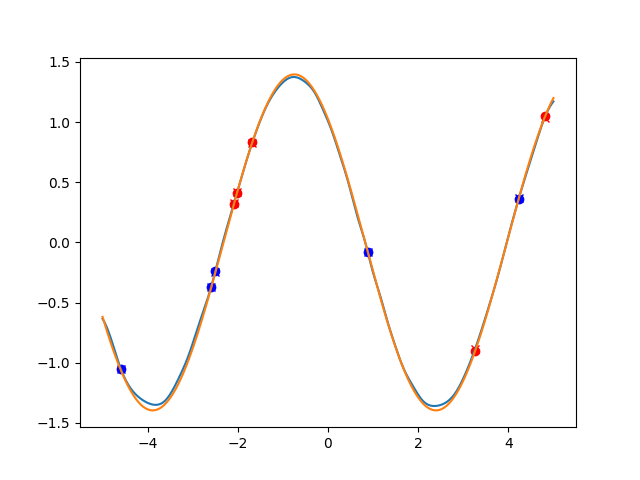

In [42]:
plt.figure()
idx  = 12
plt.plot(x1[idx], y1[idx], "bo")
plt.plot(x1[idx], y1_hat_dec[idx], "bx")

plt.plot(x2[idx], y2[idx], "ro") 
plt.plot(x2[idx], y2_hat_dec[idx], "rx")

plt.plot(x_dense,y_hat_dec[idx])
plt.plot(x_dense,meta_y_test_dense[idx])


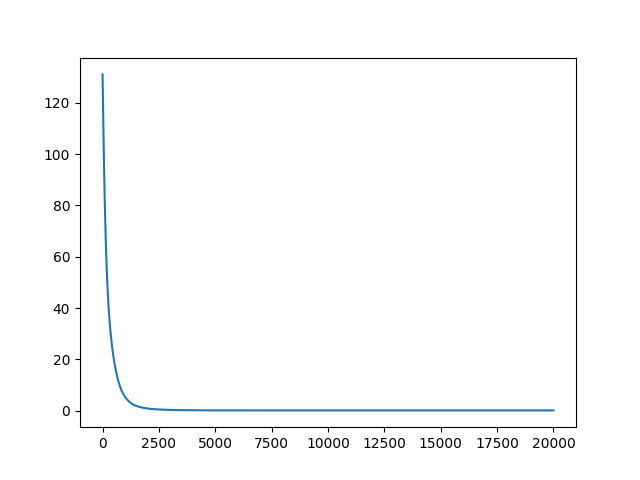

In [43]:
plt.figure()
plt.plot(train_loss_latent)

In [44]:
import jax
import jax.numpy as jnp

def compute_laplace_posterior_batched(z_map_batch, x_batch, y_batch):
    """
    Computes the Laplace approximation for a batch of tasks.
    
    Args:
        z_map_batch: The optimized MAP estimates of shape (batch_size, latent_dim)
        x_batch: Input data of shape (batch_size, N, d_x)
        y_batch: Target data of shape (batch_size, N, d_y)
        
    Returns:
        cov_matrix_batch: The posterior covariance matrices of shape (batch_size, latent_dim, latent_dim)
    """
    
    # 1. Redefine the exact same loss function used for MAP
    # (Must return ONLY the scalar loss for jax.hessian to work)
    def loss_fn_for_hessian(z, x, y):
        y_hat = mlp_emb_apply(z, params_mlp_opt, params_lift_opt, x)
        scaled_err = (y - y_hat) / (std_opt + 1e-4)

        nll_loss = 0.5 * jnp.sum(scaled_err**2) / y.shape[0]
        reg_loss = 0.5 * jnp.sum(z**2) / y.shape[0]
        
        return nll_loss + reg_loss

    # 2. Define the Hessian function with respect to the first argument (z)
    hessian_fn = jax.hessian(loss_fn_for_hessian, argnums=0)
    
    # 3. Vectorize the Hessian computation across the batch dimension
    batched_hessian_fn = jax.vmap(hessian_fn, in_axes=(0, 0, 0))
    
    # 4. Compute the Hessian matrices for the whole batch
    # Shape of hessian_batch: (batch_size, latent_dim, latent_dim)
    hessian_batch = batched_hessian_fn(z_map_batch, x_batch, y_batch)
    
    # 5. Invert the Hessian to get the Covariance matrix
    # jnp.linalg.inv automatically handles batches of matrices!
    cov_matrix_batch = jnp.linalg.inv(hessian_batch)
    
    return cov_matrix_batch

# --- How to use it ---

# 2. Compute the Laplace posterior covariance
print("Before Laplace:", jnp.sum(latent_opt))
posterior_covariances = compute_laplace_posterior_batched(latent_opt, x1, y1)
print("After Laplace:", jnp.sum(latent_opt))


# Now, for a specific environment 'i', your posterior is:
# q(z_i | x_i, y_i) ~ N(mu = latent_opt[i], cov = posterior_covariances[i])


Before Laplace: -18.351002
After Laplace: -18.351002


In [45]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

def sample_predictions_batched(keys_batch, z_mean_batch, z_cov_batch, x_batch, num_samples=100):
    
    # Define what happens for a SINGLE task/environment
    def sample_predictions_single(key, z_mean, z_cov, x_single):
        # Sample z: (num_samples, latent_dim)
        z_samples = jr.multivariate_normal(key, mean=z_mean, cov=z_cov, shape=(num_samples,))
        
        # Predict for all samples
        def predict_single_z(z):
            return mlp_emb_apply(z, params_mlp_opt, params_lift_opt, x_single)
            
        y_pred_samples = jax.vmap(predict_single_z)(z_samples)
        
        # Compute mean and std across the num_samples dimension (axis=0)
        pred_mean = jnp.mean(y_pred_samples, axis=0)
        pred_std = jnp.std(y_pred_samples, axis=0)
        return pred_mean, pred_std

    # Vmap the single-task function across the batch dimension
    # in_axes=(0, 0, 0, 0) maps over keys, means, covs, and xs
    batch_fn = jax.vmap(sample_predictions_single, in_axes=(0, 0, 0, 0))
    
    # Execute for the whole batch
    pred_mean_batch, pred_std_batch = batch_fn(keys_batch, z_mean_batch, z_cov_batch, x_batch)
    
    return pred_mean_batch, pred_std_batch

# --- Execution ---

# 1. Generate a batch of keys (one key per task)
# meta_test_size is the number of trajectories in your batch
batch_size = x1.shape[0]
base_key = jr.PRNGKey(42)
keys_batch = jr.split(base_key, batch_size)

# 2. Get predictions and uncertainties for both context (x1) and target (x2)
# (Assuming you want to plot both the context and the extrapolation/target points)
pred_mean_1, pred_std_1 = sample_predictions_batched(keys_batch, latent_opt, posterior_covariances, x1)
pred_mean_2, pred_std_2 = sample_predictions_batched(keys_batch, latent_opt, posterior_covariances, x2)
batchsize = keys_batch.shape[0]  # 100
x_dense_batch = jnp.broadcast_to(x_dense[None, :, None], (batchsize, x_dense.shape[0], 1))

pred_mean, pred_std = sample_predictions_batched(
    keys_batch, latent_opt, posterior_covariances, x_dense_batch
)


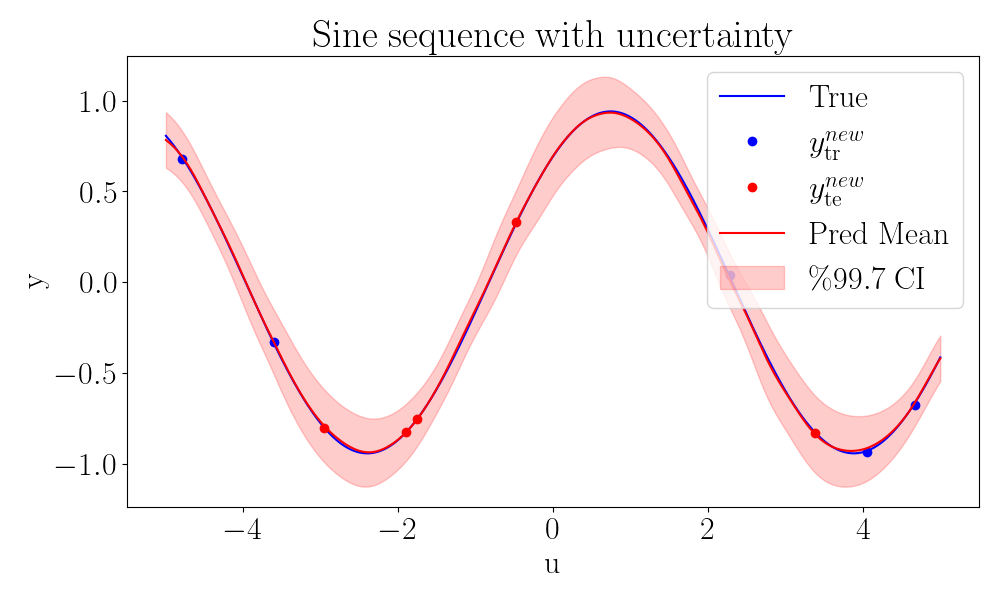

In [49]:
# --- Plotting ---
tex_fonts = {
    # Use LaTeX to write all text
   "text.usetex": True,
   "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
   "axes.labelsize": 14,
   "font.size": 14,
   "legend.fontsize": 12,
   "xtick.labelsize": 12,
   "ytick.labelsize": 12
}
plt.rcParams.update(tex_fonts)
idx =15 # Choose which task in the batch to plot

# For smooth lines and bands, we sort x and y_hat based on x values
def sort_for_plot(x, mean, std):
    # x is likely shape (N, 1), we flatten it for plotting
    x_flat = x.flatten()
    mean_flat = mean.flatten()
    std_flat = std.flatten()
    
    sort_idx = jnp.argsort(x_flat)
    return x_flat[sort_idx], mean_flat[sort_idx], std_flat[sort_idx]

x1_plot, m1_plot, s1_plot = sort_for_plot(x_dense, pred_mean[idx], pred_std[idx])
# x2_plot, m2_plot, s2_plot = sort_for_plot(x2[idx], pred_mean_2[idx], pred_std_2[idx])

plt.figure(figsize=(10, 6))


plt.plot(x_dense, meta_y_test_dense[idx].flatten(), "b", label="True")
plt.plot(x1[idx], y1[idx].flatten(), "bo", label=r'$y^{new}_{\mathrm{tr}}$')
plt.plot(x2[idx], y2[idx].flatten(), "ro", label=r'$y^{new}_{\mathrm{te}}$')
# Predictive Mean
plt.plot(x_dense, pred_mean[idx], "r-", label="Pred Mean")
# plt.plot(x2[idx], pred_mean_2[idx], "r-", label="Target Pred Mean 2")
# Uncertainty Band
plt.fill_between(x1_plot, m1_plot - 3*s1_plot, m1_plot + 3*s1_plot, color='red', alpha=0.2, label = r'$\%99.7$ CI')

plt.title(f"Sine sequence with uncertainty", fontsize = 28)
plt.xlabel("u",fontsize = 23)
plt.ylabel("y",fontsize = 23)
plt.legend(fontsize = 23)
plt.xticks(fontsize=23)
plt.yticks(fontsize=23)
plt.tight_layout()
plt.show()
plt.savefig('uncertainty_plot_10pt.pdf')

